# Module Five Activity

For the module five activity, you will write Python code to create clear and informative data visualizations from the provided data set `Most-Recent-Cohorts-Field-of-Study.csv`. Your code should be well-organized and reflect a clear understanding of each step in the visualization process. 

<div class="alert alert-block alert-danger">
    <span style="color:black"><b><i>Note:</i></b> there are two parts to this assignment. Part One is the data visualization coding activity. Part Two is the reflection paper.</span>
</div>

Once your code is complete, you will download this notebook as an HTML file by clicking **File**, then **Download As**, then **HTML (.html)** from the Jupyter menu bar. Validate that your code, output, and all six visualizations (rendered as images using the display() function) are visible in the html file before submission.

<div class="alert alert-block alert-danger">
    <span style="color:black"><b><i>Missing Blocks:</i></b> Ensure that you have clicked <b><mark>Run</mark></b> for all blocks before downloading as an HTML file or the block may be missing from your submission. <b>Images</b> must be called using the <b><i>display()</i></b> function, for example: <b><mark>display(Image(filename="output/{image_name}.png"))</mark></b></span>
</div>

Specifically, you must address the items from the rubric criteria.

### Part One: Data Visualization

#### Prepare the given data set for visualization. Consider the following:  
- Are there any columns you can remove? 
- Are filters or groupings needed? 
- Are the data values structured for your chart types? 

#### Clean the given data set for visualization using Python. Consider the following:  
- Are there any missing or invalid values?  
- Are there any unclear column names? 
- Are the data types correct for each column (e.g., numeric, categorical, datetime)? 

#### Create multiple types of visualizations using Python.  Include the following: 
- Dendrogram 
- PCA scatterplot 
- Cluster size distribution 
- Feature importance heatmap 
- Trend chart 
- Scatterplot

<div class="alert alert-block alert-danger">
    <span style="color:black"><b><i>Note:</i></b> You will need to ensure that you have created at least one of each of the visual types listed above.</span>
</div>

### Part 2: Reflection
<i>This part is to be completed in a word document, using the output here to answer the topics.</i>

#### Identify patterns in the data. Consider the following:  
- Are there any clear trends, clusters, or outliers visible in your visualizations? 
- Are certain variables showing consistent behavior or relationships? 
- Are the patterns similar across different visualization types? 

#### Draw conclusions from the patterns. Consider the following:  
- Are your conclusions clearly based on the patterns you observed? 
- Are your findings supported by multiple visuals or data points? 


#### Explain how the visualizations validate your findings. Consider the following:  
- Are specific chart elements (e.g., color, scale, labels) helping to highlight your findings? 
- Are the insights you found something you could not easily see without the visuals? 

#### Write a summary of the visualization choices you made. Include the following:  
- An explanation of the types of charts you used 
- An explanation of the formatting decisions to support visual clarity

<div class="alert alert-block alert-success">
    <span style="color:black"><b><i>To Begin:</i></b> This Python template program has been broken down into segments as a guide for what steps you should do at a minimum to complete this activity. Look for the <b># To Do:</b> comments. These are placeholders for you to provide Python code segments. Fill out all <b># To Do:</b> code segments to complete this program.</span><br/><br/>
    <span style="color:black"><b><i>Once Complete:</i></b> Execute a "Kernel restart and run all" to verify that all your code works as a single unit by clicking <b>Kernel</b>, then <b>Restart & Run All</b> before downloading as html.</span>
</div>

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hint:</i></b> If you need to install additional packages, see one of the earlier modules on how to configure and call a requirements.txt file.</span>
</div>

## Import the Required Packages
- **pandas (pd):** For reading and manipulating the dataset.
- **MinMaxScaler:** A preprocessing tool from sklearn to normalize data values between 0 and 1.
- **PCA:** Principal Component Analysis (dimensionality reduction) from sklearn for visualizing clusters in 2D.
- **dendrogram, linkage, fcluster:** Tools from scipy for performing hierarchical clustering and visualizing its results.
- **matplotlib.pyplot (plt):** For creating charts and saving visuals.
- **seaborn (sns):** For advanced and visually appealing charts.
- **numpy (np):** For numerical operations like arrays and aggregations.

In [2]:
import pandas as pd   # for reading & manipulating the dataset
from sklearn.preprocessing import MinMaxScaler    # a preprocessing tool from sklearn to normalize data values
                                                                                    # between 0 and 1
from sklearn.decomposition import PCA  # Principal Component Analysis (dimensionality reduction) from 
                                                                   # sklearn for visualizing clusters in 2D
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster    # tools from scipy for performing hierarchical clustering & visualizing its results
import matplotlib.pyplot as plt     #  for creating charts & saving visuals
import seaborn as sns    #  for advanced & visually appealing charts
import numpy as np      # for numerical operations like arrays & aggregations

from IPython.display import Image, display # for image rendering in html output

# Part One: Data Visualization

## Loading the Data

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> Use <b><mark>pd.read_csv</mark></b> to read a CSV file and load it into a DataFrame (data). Use <b><mark>try block</mark></b> to ensures the program handles errors gracefully if the file cannot be loaded (e.g., missing or incorrect path). Use <b><mark>exit()</mark></b> to stop the program if an error occurs.</span>
</div>

In [3]:
print("Loading dataset...")

try:
    df = pd.read_csv(
        "data/Most-Recent-Cohorts-Field-of-Study.csv",
        low_memory=False
    )

    print("Dataset loaded successfully.")

except FileNotFoundError:
    print("Error: The dataset was not found in the data folder.")

except pd.errors.EmptyDataError:
    print("Error: The dataset is empty.")

Loading dataset...
Dataset loaded successfully.


## Display Dataset Information

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> Use <b><mark>data.columns.tolist()</mark></b> to extract and print all column names. Use <b><mark>data.index.tolist()</mark></b> to show the index values of the dataset (e.g., row numbers). Use <b><mark>data.head()</mark></b> to display the top 5 rows to give an overview of the data.</span>
</div>

In [4]:
print("Column Names:")

# Print all column names
print(df.columns.tolist())

Column Names:
['UNITID', 'OPEID6', 'INSTNM', 'CONTROL', 'MAIN', 'CIPCODE', 'CIPDESC', 'CREDLEV', 'CREDDESC', 'IPEDSCOUNT1', 'IPEDSCOUNT2', 'DEBT_ALL_STGP_ANY_N', 'DEBT_ALL_STGP_ANY_MEAN', 'DEBT_ALL_STGP_ANY_MDN', 'DEBT_ALL_STGP_EVAL_N', 'DEBT_ALL_STGP_EVAL_MEAN', 'DEBT_ALL_STGP_EVAL_MDN', 'DEBT_ALL_PP_ANY_N', 'DEBT_ALL_PP_ANY_MEAN', 'DEBT_ALL_PP_ANY_MDN', 'DEBT_ALL_PP_EVAL_N', 'DEBT_ALL_PP_EVAL_MEAN', 'DEBT_ALL_PP_EVAL_MDN', 'DEBT_MALE_STGP_ANY_N', 'DEBT_MALE_STGP_ANY_MEAN', 'DEBT_MALE_STGP_ANY_MDN', 'DEBT_MALE_STGP_EVAL_N', 'DEBT_MALE_STGP_EVAL_MEAN', 'DEBT_MALE_STGP_EVAL_MDN', 'DEBT_MALE_PP_ANY_N', 'DEBT_MALE_PP_ANY_MEAN', 'DEBT_MALE_PP_ANY_MDN', 'DEBT_MALE_PP_EVAL_N', 'DEBT_MALE_PP_EVAL_MEAN', 'DEBT_MALE_PP_EVAL_MDN', 'DEBT_NOTMALE_STGP_ANY_N', 'DEBT_NOTMALE_STGP_ANY_MEAN', 'DEBT_NOTMALE_STGP_ANY_MDN', 'DEBT_NOTMALE_STGP_EVAL_N', 'DEBT_NOTMALE_STGP_EVAL_MEAN', 'DEBT_NOTMALE_STGP_EVAL_MDN', 'DEBT_NOTMALE_PP_ANY_N', 'DEBT_NOTMALE_PP_ANY_MEAN', 'DEBT_NOTMALE_PP_ANY_MDN', 'DEBT_NOTMALE_

In [5]:
print("Row Index Labels:")

# Print all row index labels
print(df.index.tolist())

Row Index Labels:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 2

In [6]:
print("First 5 Rows of the Dataset:")

# Print the first five rows
display(df.head())

First 5 Rows of the Dataset:


,UNITID,OPEID6,INSTNM,CONTROL,MAIN,CIPCODE,CIPDESC,CREDLEV,CREDDESC,IPEDSCOUNT1,...,EARN_COUNT_PELL_WNE_5YR,EARN_PELL_WNE_MDN_5YR,EARN_COUNT_NOPELL_WNE_5YR,EARN_NOPELL_WNE_MDN_5YR,EARN_COUNT_MALE_WNE_5YR,EARN_MALE_WNE_MDN_5YR,EARN_COUNT_NOMALE_WNE_5YR,EARN_NOMALE_WNE_MDN_5YR,EARN_COUNT_HIGH_CRED_5YR,EARN_IN_STATE_5YR
0,100654.0,1002,Alabama A & M University,Public,1,100,"Agriculture, General.",3,Bachelor's Degree,NaN,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
1,100654.0,1002,Alabama A & M University,Public,1,101,Agricultural Business and Management.,3,Bachelor's Degree,NaN,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
2,100654.0,1002,Alabama A & M University,Public,1,109,Animal Sciences.,3,Bachelor's Degree,3.0,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
3,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,3,Bachelor's Degree,7.0,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
4,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,5,Master's Degree,4.0,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS


## Inspect and Select Numeric Columns

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> Use <b><mark>select_dtypes()</mark></b> to filter columns with numeric data types (float64 and int64). Removes columns like <b><mark>UNITID</mark></b> and <b><mark>OPEID6</mark></b>, which are not useful for clustering. Use <b><mark>dropna()</mark></b> to remove rows with missing values to clean data for clustering, see also module three sample for additional cleaning examples. Use error handling <b><mark>try blocks</mark></b> to ensures the program stops if the column selection fails.</span>
</div>

In [7]:
print("Inspecting dataset to select numeric columns for clustering...")

try:
    # Select only numeric columns
    numeric_data = df.select_dtypes(include=["float64", "int64"])

    # Remove identifier columns
    numeric_data = numeric_data.drop(
        columns=["UNITID", "OPEID6"],
        errors="ignore"
    )

    # Remove rows containing missing values
    data_for_clustering = numeric_data.dropna()

    if data_for_clustering.empty:
        raise ValueError(
            "No complete rows remain after removing missing values."
        )

    print("Numeric Columns Selected for Clustering:")
    print(data_for_clustering.columns.tolist())

    print("\nClustering Data Dimensions:")
    print(f"Rows: {data_for_clustering.shape[0]:,}")
    print(f"Columns: {data_for_clustering.shape[1]}")

    display(data_for_clustering.head())

except Exception as error:
    print(f"Error selecting numeric columns: {error}")
    raise

Inspecting dataset to select numeric columns for clustering...
Numeric Columns Selected for Clustering:
['MAIN', 'CIPCODE', 'CREDLEV', 'IPEDSCOUNT1', 'IPEDSCOUNT2', 'DISTANCE']

Clustering Data Dimensions:
Rows: 184,861
Columns: 6


,MAIN,CIPCODE,CREDLEV,IPEDSCOUNT1,IPEDSCOUNT2,DISTANCE
2,1,109,3,3.0,9.0,1
3,1,110,3,7.0,10.0,1
4,1,110,5,4.0,6.0,1
5,1,110,6,2.0,4.0,1
7,1,199,3,6.0,6.0,1


## Normalize the Data

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> Use <b><mark>MinMaxScaler()</mark></b> to scale data values between 0 and 1, ensuring all features are on the same scale. Use <b><mark>fit_transform()</mark></b> to fit the scaler to the data and transform it.</span>
</div>

In [8]:
print("Normalizing the data using MinMaxScaler...")

try:
    scaler = MinMaxScaler()

    scaled_data = scaler.fit_transform(data_for_clustering)

    normalized_data = pd.DataFrame(
        scaled_data,
        columns=data_for_clustering.columns,
        index=data_for_clustering.index
    )

    print("Data normalized successfully.")
    print(f"Rows: {normalized_data.shape[0]:,}")
    print(f"Columns: {normalized_data.shape[1]}")

    display(normalized_data.head())

except Exception as error:
    print(f"Error normalizing the data: {error}")
    raise

Normalizing the data using MinMaxScaler...
Data normalized successfully.
Rows: 184,861
Columns: 6


,MAIN,CIPCODE,CREDLEV,IPEDSCOUNT1,IPEDSCOUNT2,DISTANCE
2,1.0,0.001698,0.285714,0.000330,0.000937,0.0
3,1.0,0.001886,0.285714,0.000771,0.001041,0.0
4,1.0,0.001886,0.571429,0.000440,0.000625,0.0
5,1.0,0.001886,0.714286,0.000220,0.000416,0.0
7,1.0,0.018676,0.285714,0.000661,0.000625,0.0


## Perform Hierarchical Clustering

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> Use <b><mark>linkage()</mark></b> to compute hierarchical clusters using <b><mark>Ward's</mark></b> method, which minimizes variance between clusters. Limit clustering to the first 1000 rows for performance. Use <b><mark>fcluster()</mark></b> to assign cluster labels to data points based on the number of clusters (max_clusters).</span>
</div>

In [10]:
print("Performing hierarchical clustering using Ward's method...")

try:
    # Limit the sample because hierarchical clustering has high memory usage
    maximum_rows = 2000

    if len(data_for_clustering) > maximum_rows:
        clustering_data = data_for_clustering.sample(
            n=maximum_rows,
            random_state=42
        )
    else:
        clustering_data = data_for_clustering.copy()

    if len(clustering_data) < 2:
        raise ValueError(
            "At least two rows are required for hierarchical clustering."
        )

    # Normalize the sampled data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(clustering_data)

    normalized_data = pd.DataFrame(
        scaled_data,
        columns=clustering_data.columns,
        index=clustering_data.index
    )

    # Perform hierarchical clustering
    linkage_matrix = linkage(
        scaled_data,
        method="ward"
    )

    # Create a maximum of four clusters
    cluster_labels = fcluster(
        linkage_matrix,
        t=4,
        criterion="maxclust"
    )

    clustered_data = clustering_data.copy()
    clustered_data["Cluster"] = cluster_labels

    print("Hierarchical clustering completed successfully.")
    print(f"Rows used: {len(clustering_data):,}")
    print(f"Number of clusters: {len(np.unique(cluster_labels))}")

    print("\nCluster Sizes:")
    print(clustered_data["Cluster"].value_counts().sort_index())

except Exception as error:
    print(f"Error performing hierarchical clustering: {error}")
    raise

Performing hierarchical clustering using Ward's method...
Hierarchical clustering completed successfully.
Rows used: 2,000
Number of clusters: 4

Cluster Sizes:
Cluster
1     294
2    1007
3     596
4     103
Name: count, dtype: int64


## Generate, Save, and Output Visualizations

Each visualization is created, saved and displayed, with text output provided before and after.

### Dendrogram

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> A dendrogram displays the hierarchical structure of clusters. Save the image as <b><mark>dendrogram.png</mark></b>. Use <b><mark>display()</mark></b> to render the image for html file output. Do not use an <mark>html image</mark> tag in the markdown, or the image will not print in the html download.</span>
</div>

In [13]:
print("Creating dendrogram to visualize hierarchical clustering...")

try:
    from pathlib import Path
    from IPython.display import Image, display

    # Create the output folder if it does not already exist
    output_folder = Path("output")
    output_folder.mkdir(exist_ok=True)

    dendrogram_path = output_folder / "dendrogram.png"

    plt.figure(figsize=(14, 8))

    dendrogram(
        linkage_matrix,
        truncate_mode="lastp",
        p=30,
        leaf_rotation=90,
        leaf_font_size=8,
        show_contracted=True
    )

    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Clustered Groups")
    plt.ylabel("Ward Distance")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    plt.savefig(
        dendrogram_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

except Exception as error:
    print(f"Error creating dendrogram: {error}")
    raise

Creating dendrogram to visualize hierarchical clustering...


Dendrogram visualization display...


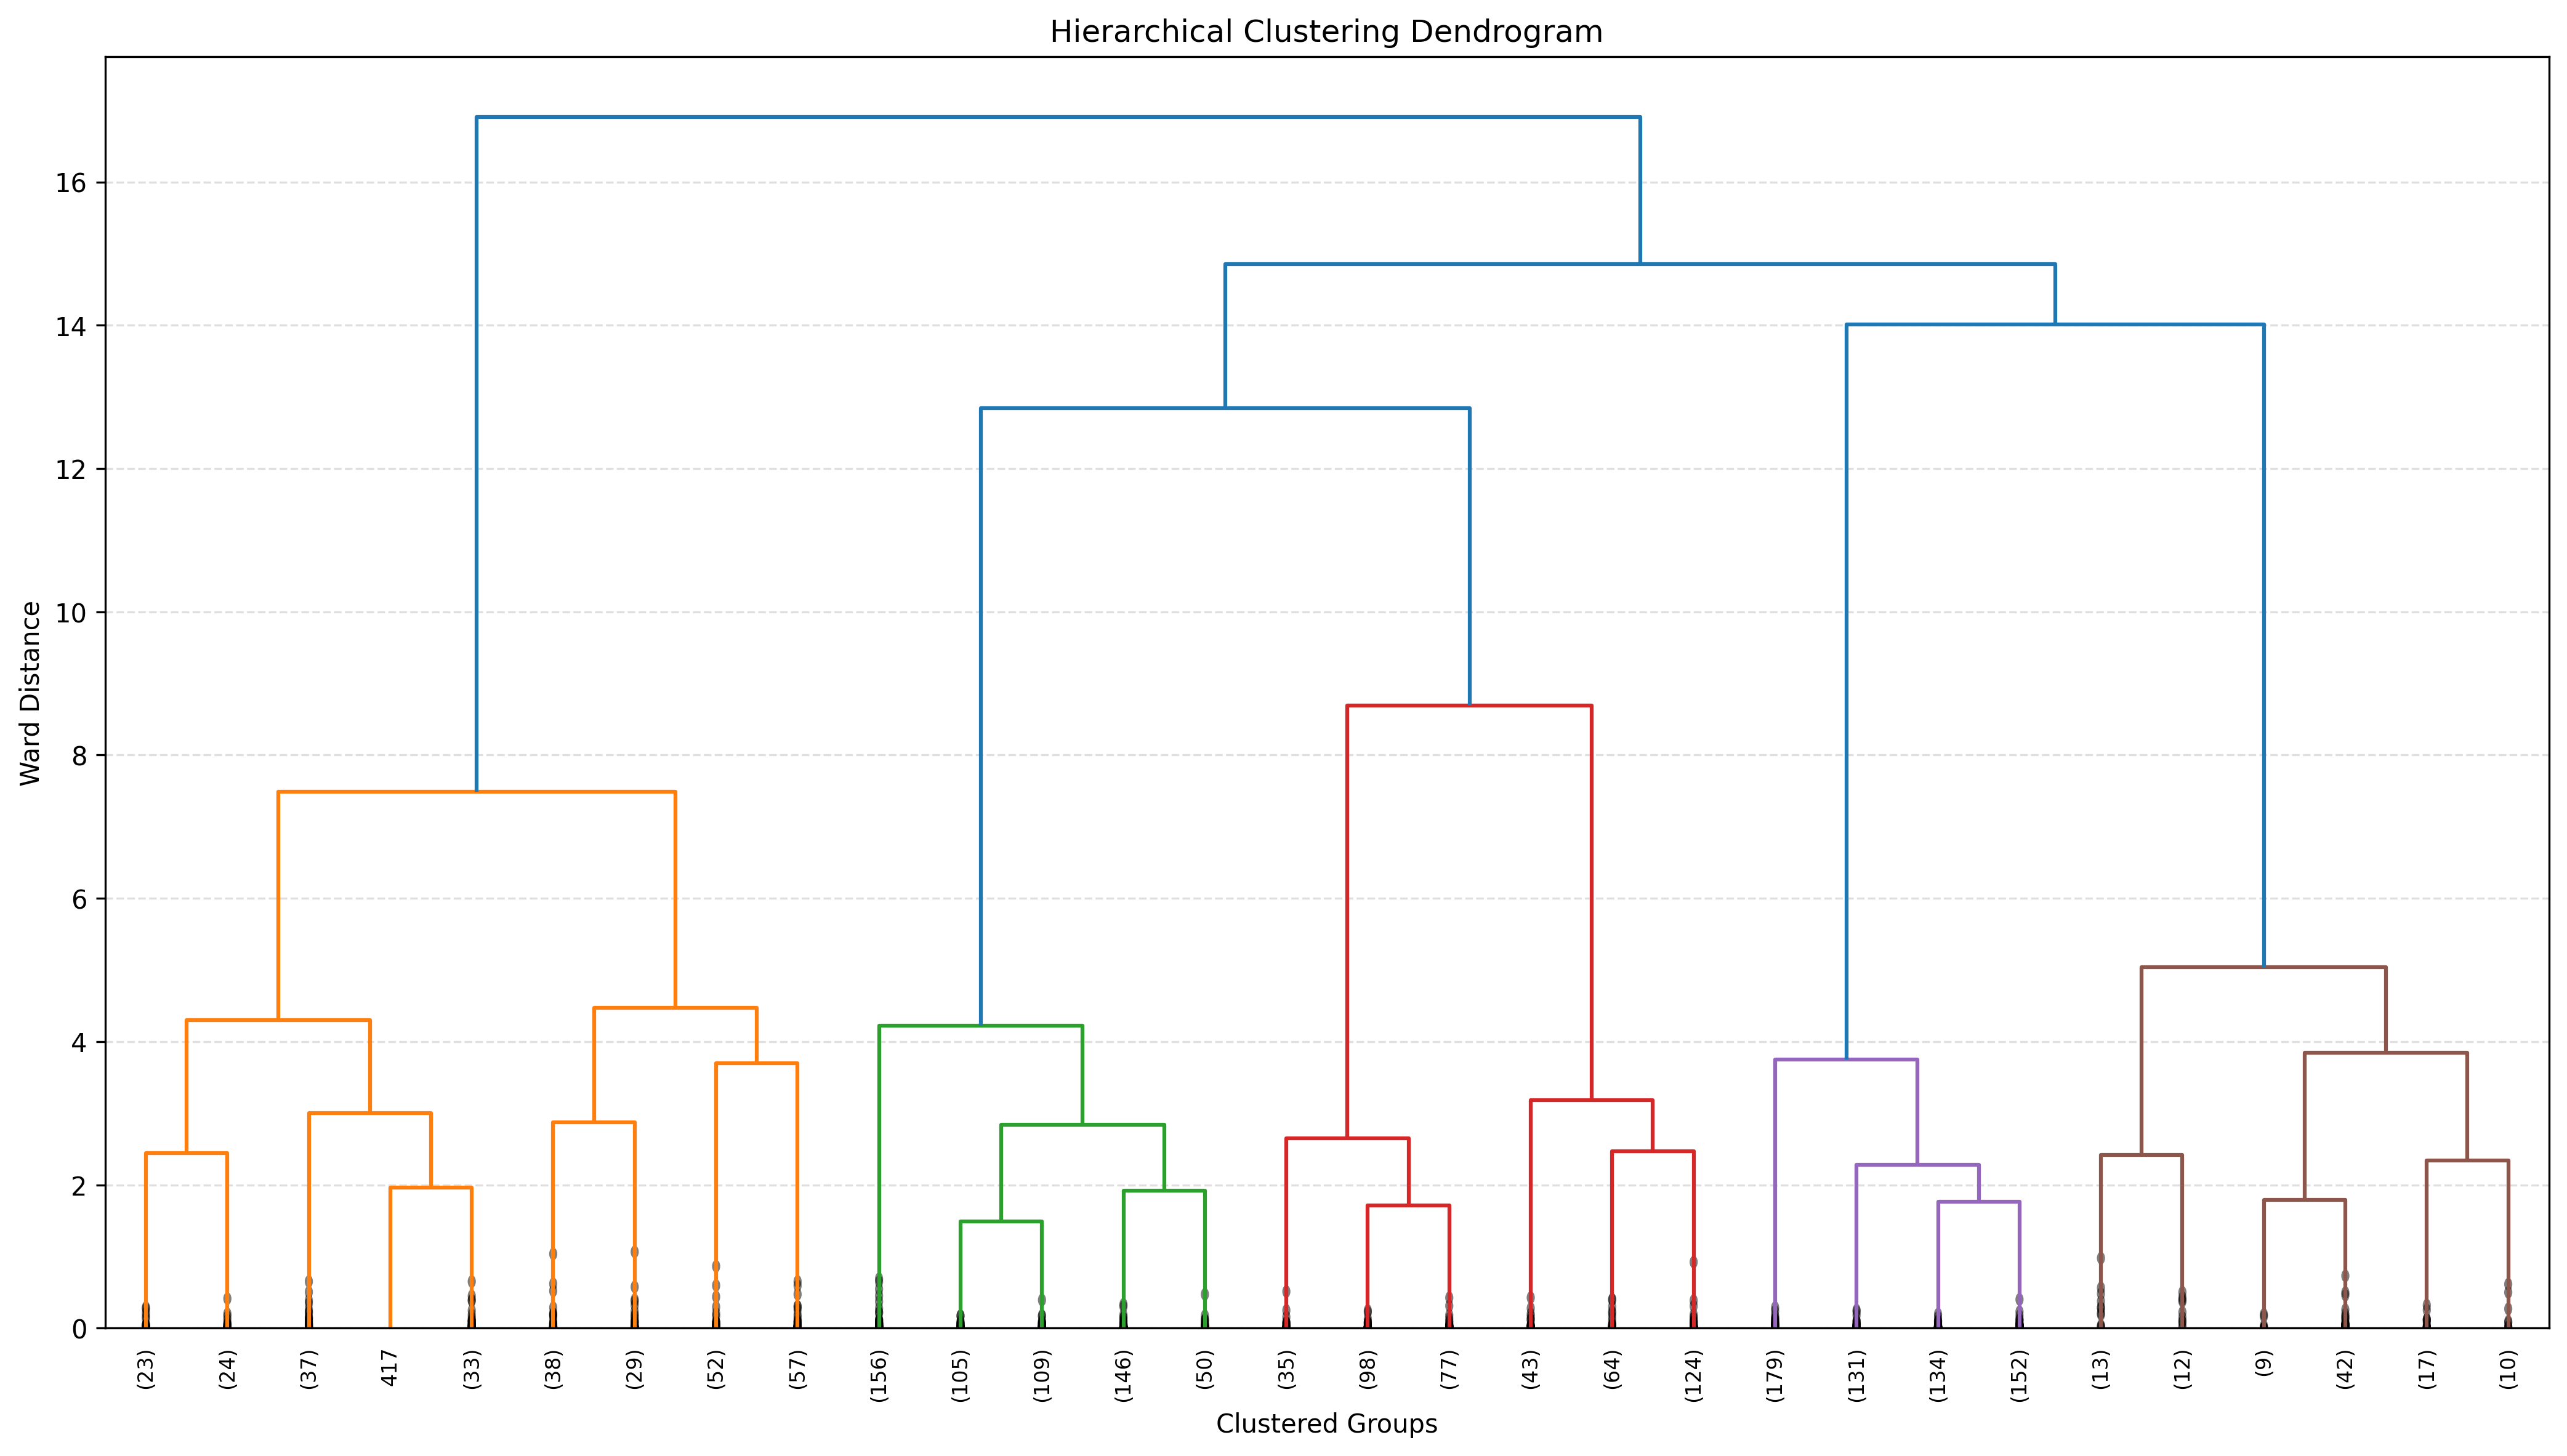

In [12]:
print("Dendrogram visualization display...")

display(Image(filename="output/dendrogram.png"))

### PCA Scatter Plot

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> A PCA scatter plot projects high-dimensional data into 2D using PCA for visualization. Save the image as <b><mark>pca_scatter_plot.png</mark></b>. Use <b><mark>display()</mark></b> to render the image for html file output. Do not use an <mark>html image</mark> tag in the markdown, or the image will not print in the html download.</span>
</div>

In [14]:
print("Creating scatter plot (PCA Reduced) to visualize clusters in 2D...")

try:
    # Reduce the normalized features to two principal components
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)

    # Create a DataFrame for plotting
    pca_data = pd.DataFrame(
        {
            "Principal Component 1": pca_result[:, 0],
            "Principal Component 2": pca_result[:, 1],
            "Cluster": cluster_labels.astype(str)
        }
    )

    pca_scatter_path = output_folder / "pca_scatter_plot.png"

    plt.figure(figsize=(12, 8))

    sns.scatterplot(
        data=pca_data,
        x="Principal Component 1",
        y="Principal Component 2",
        hue="Cluster",
        palette="Set2",
        s=55,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.3
    )

    explained_variance = pca.explained_variance_ratio_ * 100

    plt.xlabel(
        f"Principal Component 1 ({explained_variance[0]:.1f}% variance)"
    )
    plt.ylabel(
        f"Principal Component 2 ({explained_variance[1]:.1f}% variance)"
    )
    plt.title("PCA Scatter Plot of Hierarchical Clusters")
    plt.legend(title="Cluster")
    plt.grid(linestyle="--", alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        pca_scatter_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"PCA scatter plot saved as: {pca_scatter_path}")

except Exception as error:
    print(f"Error creating PCA scatter plot: {error}")
    raise

Creating scatter plot (PCA Reduced) to visualize clusters in 2D...
PCA scatter plot saved as: output/pca_scatter_plot.png


PCA scatter plot visualization display...


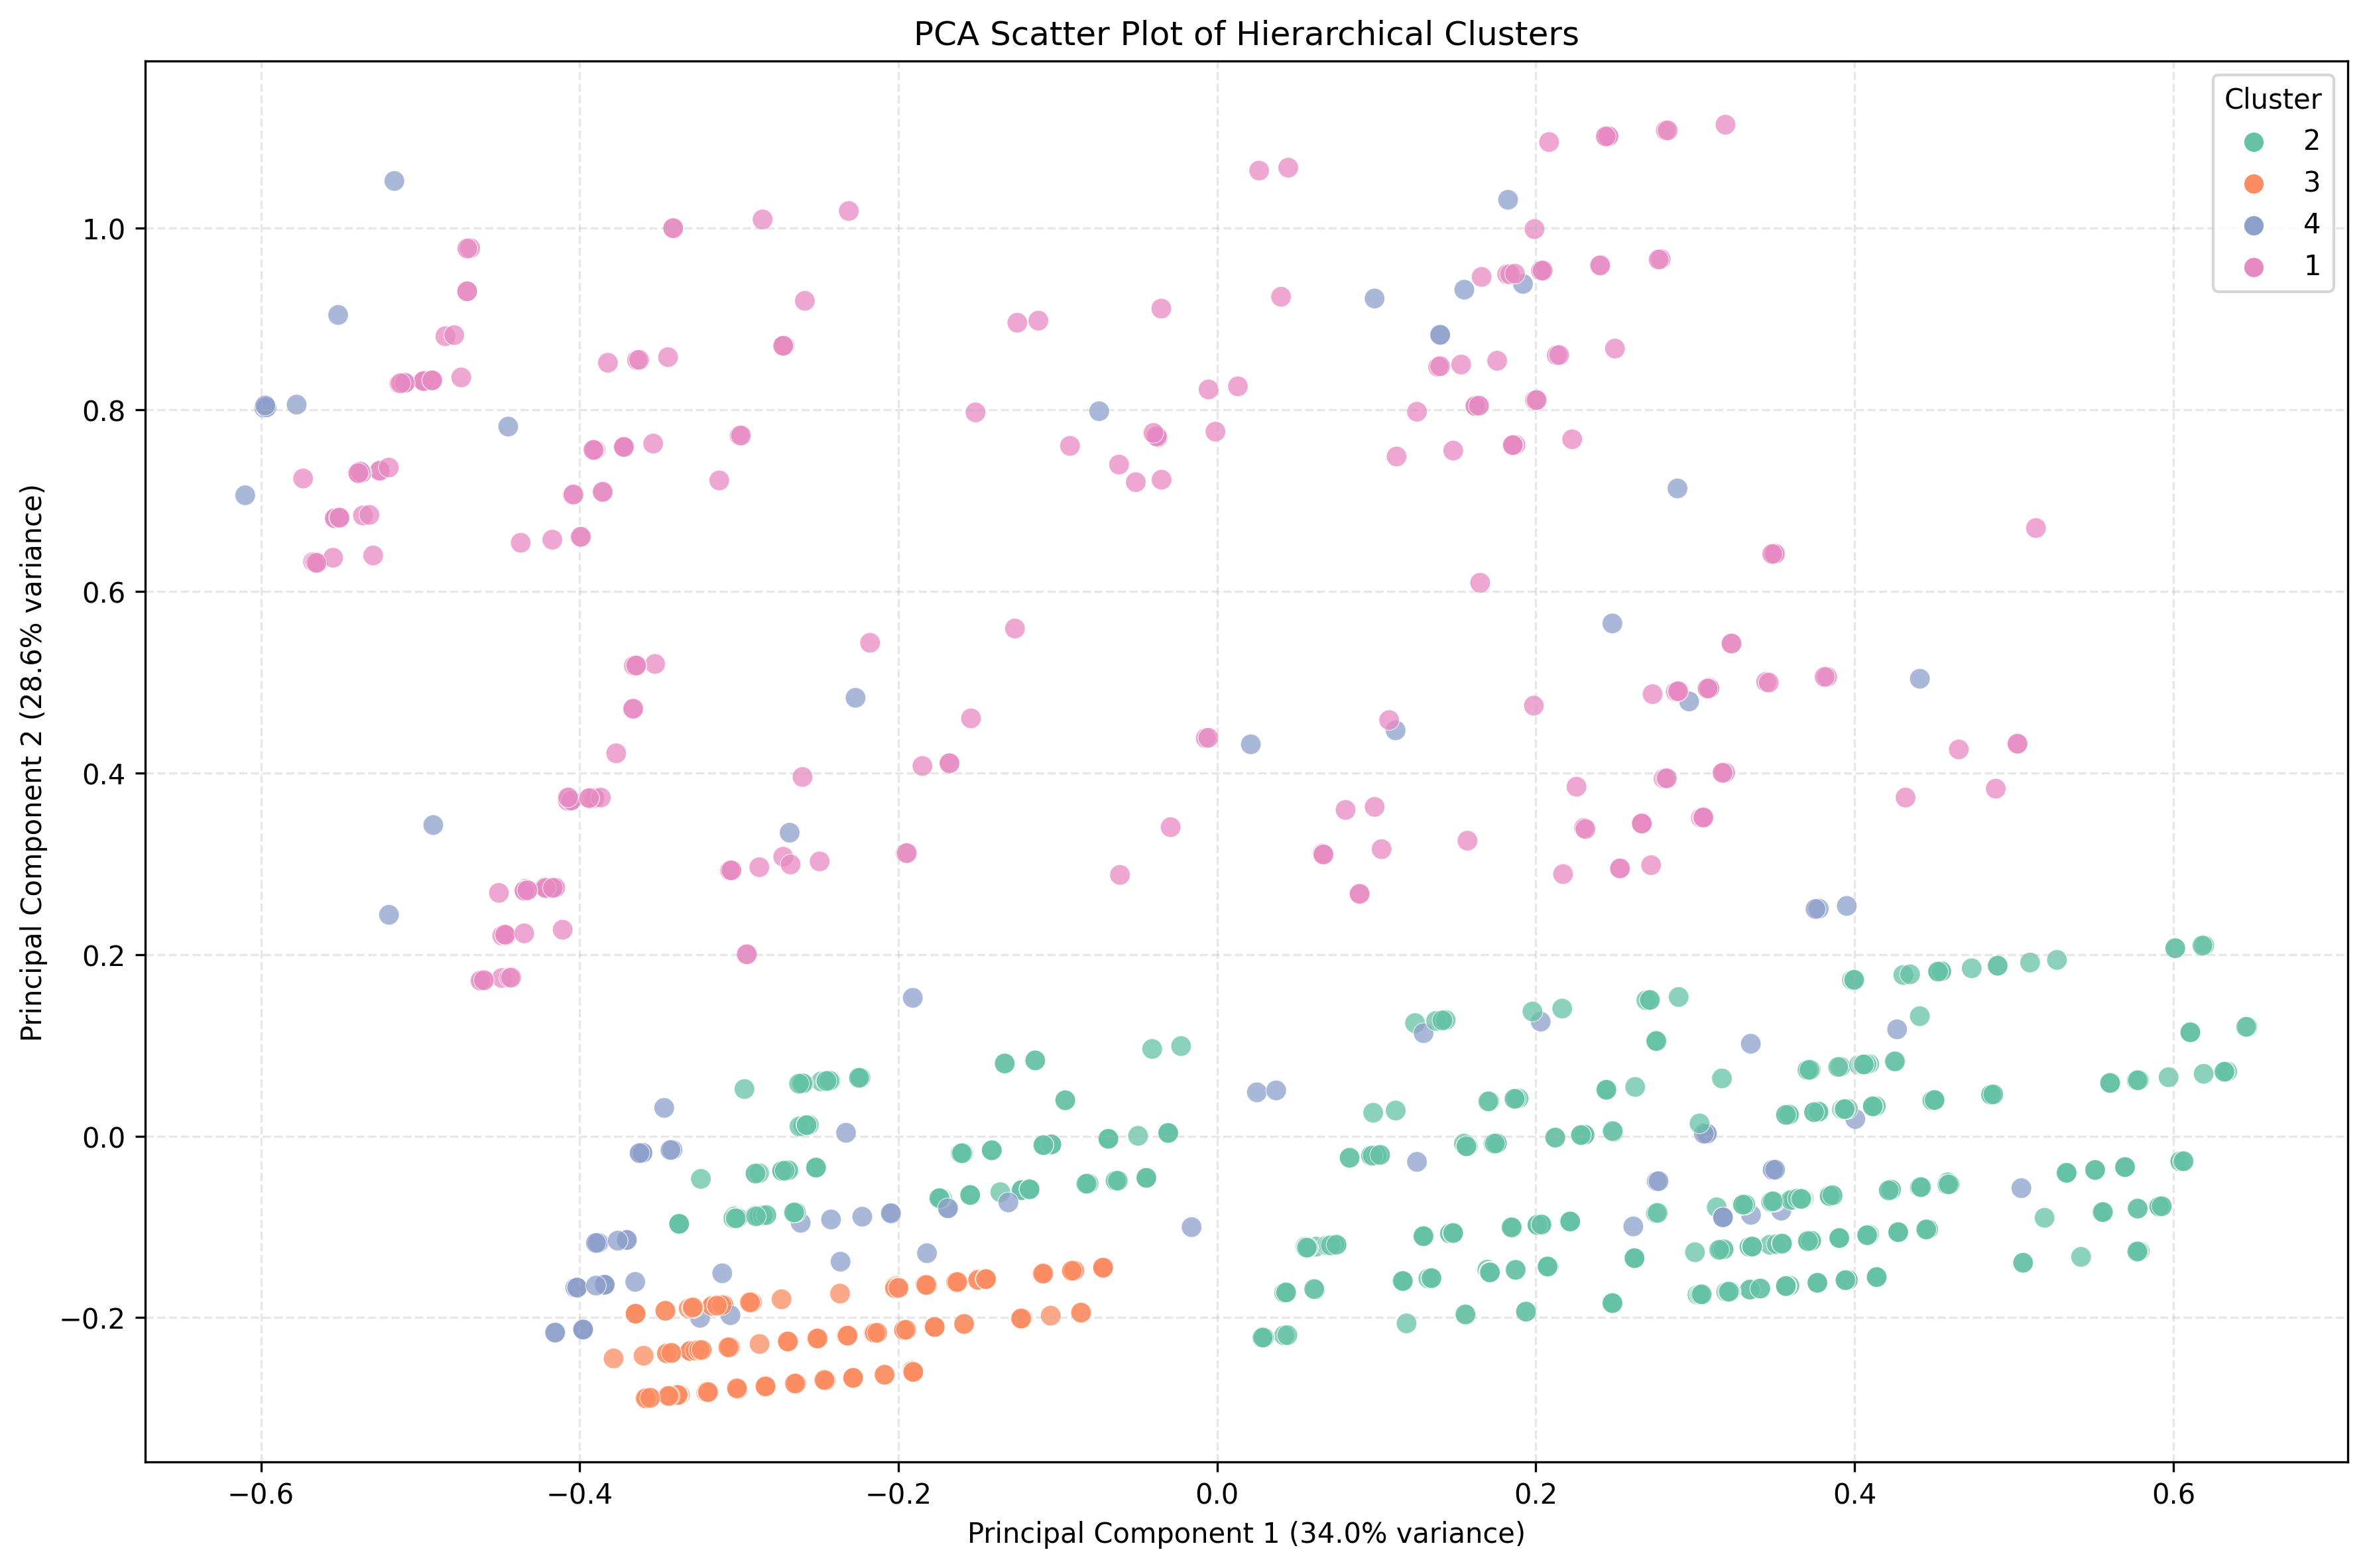

In [15]:
print("PCA scatter plot visualization display...")

display(Image(filename="output/pca_scatter_plot.png"))

### Cluster Size Distribution

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> A cluster size distribution displays the population size of each cluster. Save the image as <b><mark>cluster_size.png</mark></b>. Use <b><mark>display()</mark></b> to render the image for html file output. Do not use an <mark>html image</mark> tag in the markdown, or the image will not print in the html download.</span>
</div>

In [16]:
print("Creating cluster size distribution chart to analyze cluster populations...")

try:
    # Count the number of observations assigned to each cluster
    cluster_sizes = (
        pd.Series(cluster_labels, name="Cluster")
        .value_counts()
        .sort_index()
    )

    cluster_size_path = output_folder / "cluster_size.png"

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        cluster_sizes.index.astype(str),
        cluster_sizes.values,
        color=sns.color_palette("Set2", len(cluster_sizes)),
        edgecolor="black",
        linewidth=0.7
    )

    # Display the population above each bar
    for bar, population in zip(bars, cluster_sizes.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{population:,}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title("Cluster Size Distribution")
    plt.xlabel("Cluster")
    plt.ylabel("Number of Observations")
    plt.xticks(cluster_sizes.index.astype(str))
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        cluster_size_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Cluster size distribution saved as: {cluster_size_path}")

except Exception as error:
    print(f"Error creating cluster size distribution: {error}")
    raise

Creating cluster size distribution chart to analyze cluster populations...
Cluster size distribution saved as: output/cluster_size.png


Cluster size distribution visualization display...


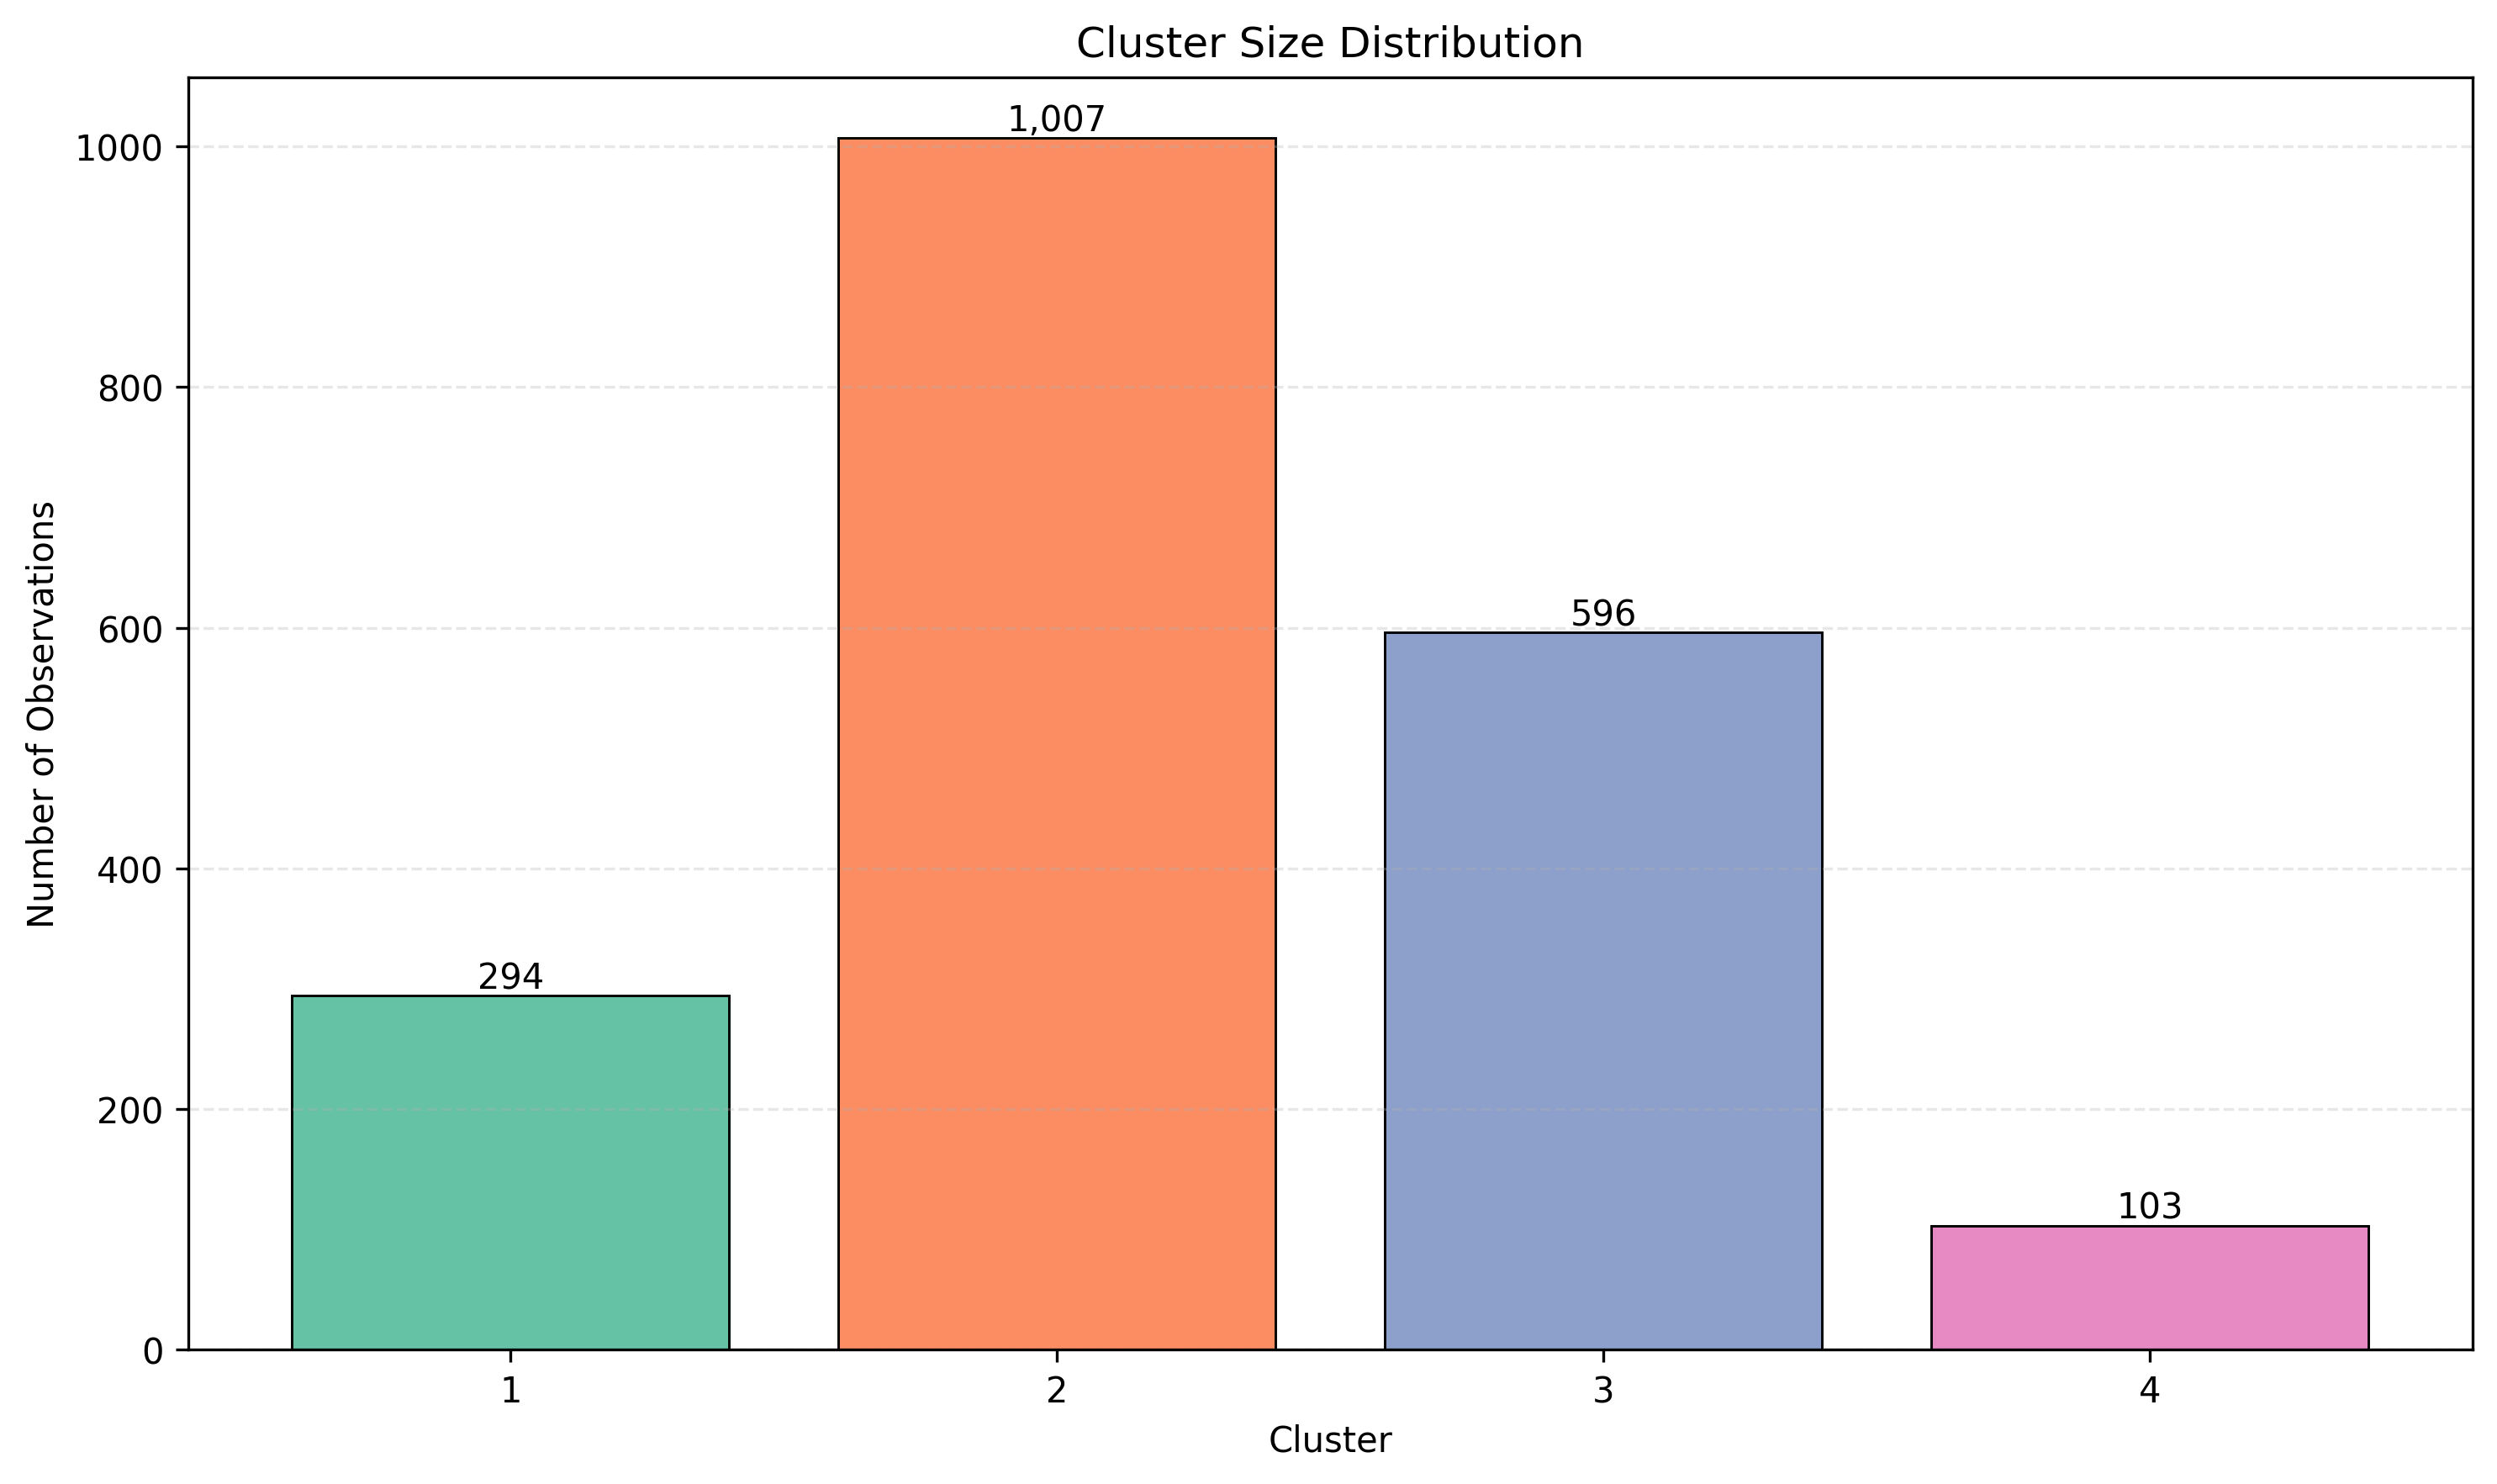

In [17]:
print("Cluster size distribution visualization display...")

display(Image(filename="output/cluster_size.png"))

### Feature Importance Heatmap

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> A feature importance heatmap highlights the average feature values for each cluster. Save the image as <b><mark>heatmap.png</mark></b>. Use <b><mark>display()</mark></b> to render the image for html file output. Do not use an <mark>html image</mark> tag in the markdown, or the image will not print in the html download.</span>
</div>

In [18]:
print("Creating feature importance heatmap to show mean feature values by cluster...")

try:
    # Add cluster labels to the normalized feature data
    heatmap_source = normalized_data.copy()
    heatmap_source["Cluster"] = cluster_labels

    # Calculate the mean normalized value of each feature by cluster
    cluster_feature_means = heatmap_source.groupby("Cluster").mean()

    # Select the 15 features that vary the most across clusters
    feature_variation = (
        cluster_feature_means.var(axis=0)
        .sort_values(ascending=False)
    )

    important_features = feature_variation.head(15).index
    heatmap_data = cluster_feature_means[important_features].T

    heatmap_path = output_folder / "heatmap.png"

    plt.figure(figsize=(10, 12))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        cbar_kws={"label": "Mean Normalized Value"}
    )

    plt.title("Mean Feature Values by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(
        heatmap_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Feature importance heatmap saved as: {heatmap_path}")

except Exception as error:
    print(f"Error creating feature importance heatmap: {error}")
    raise

Creating feature importance heatmap to show mean feature values by cluster...
Feature importance heatmap saved as: output/heatmap.png


Feature importance heatmap visualization display...


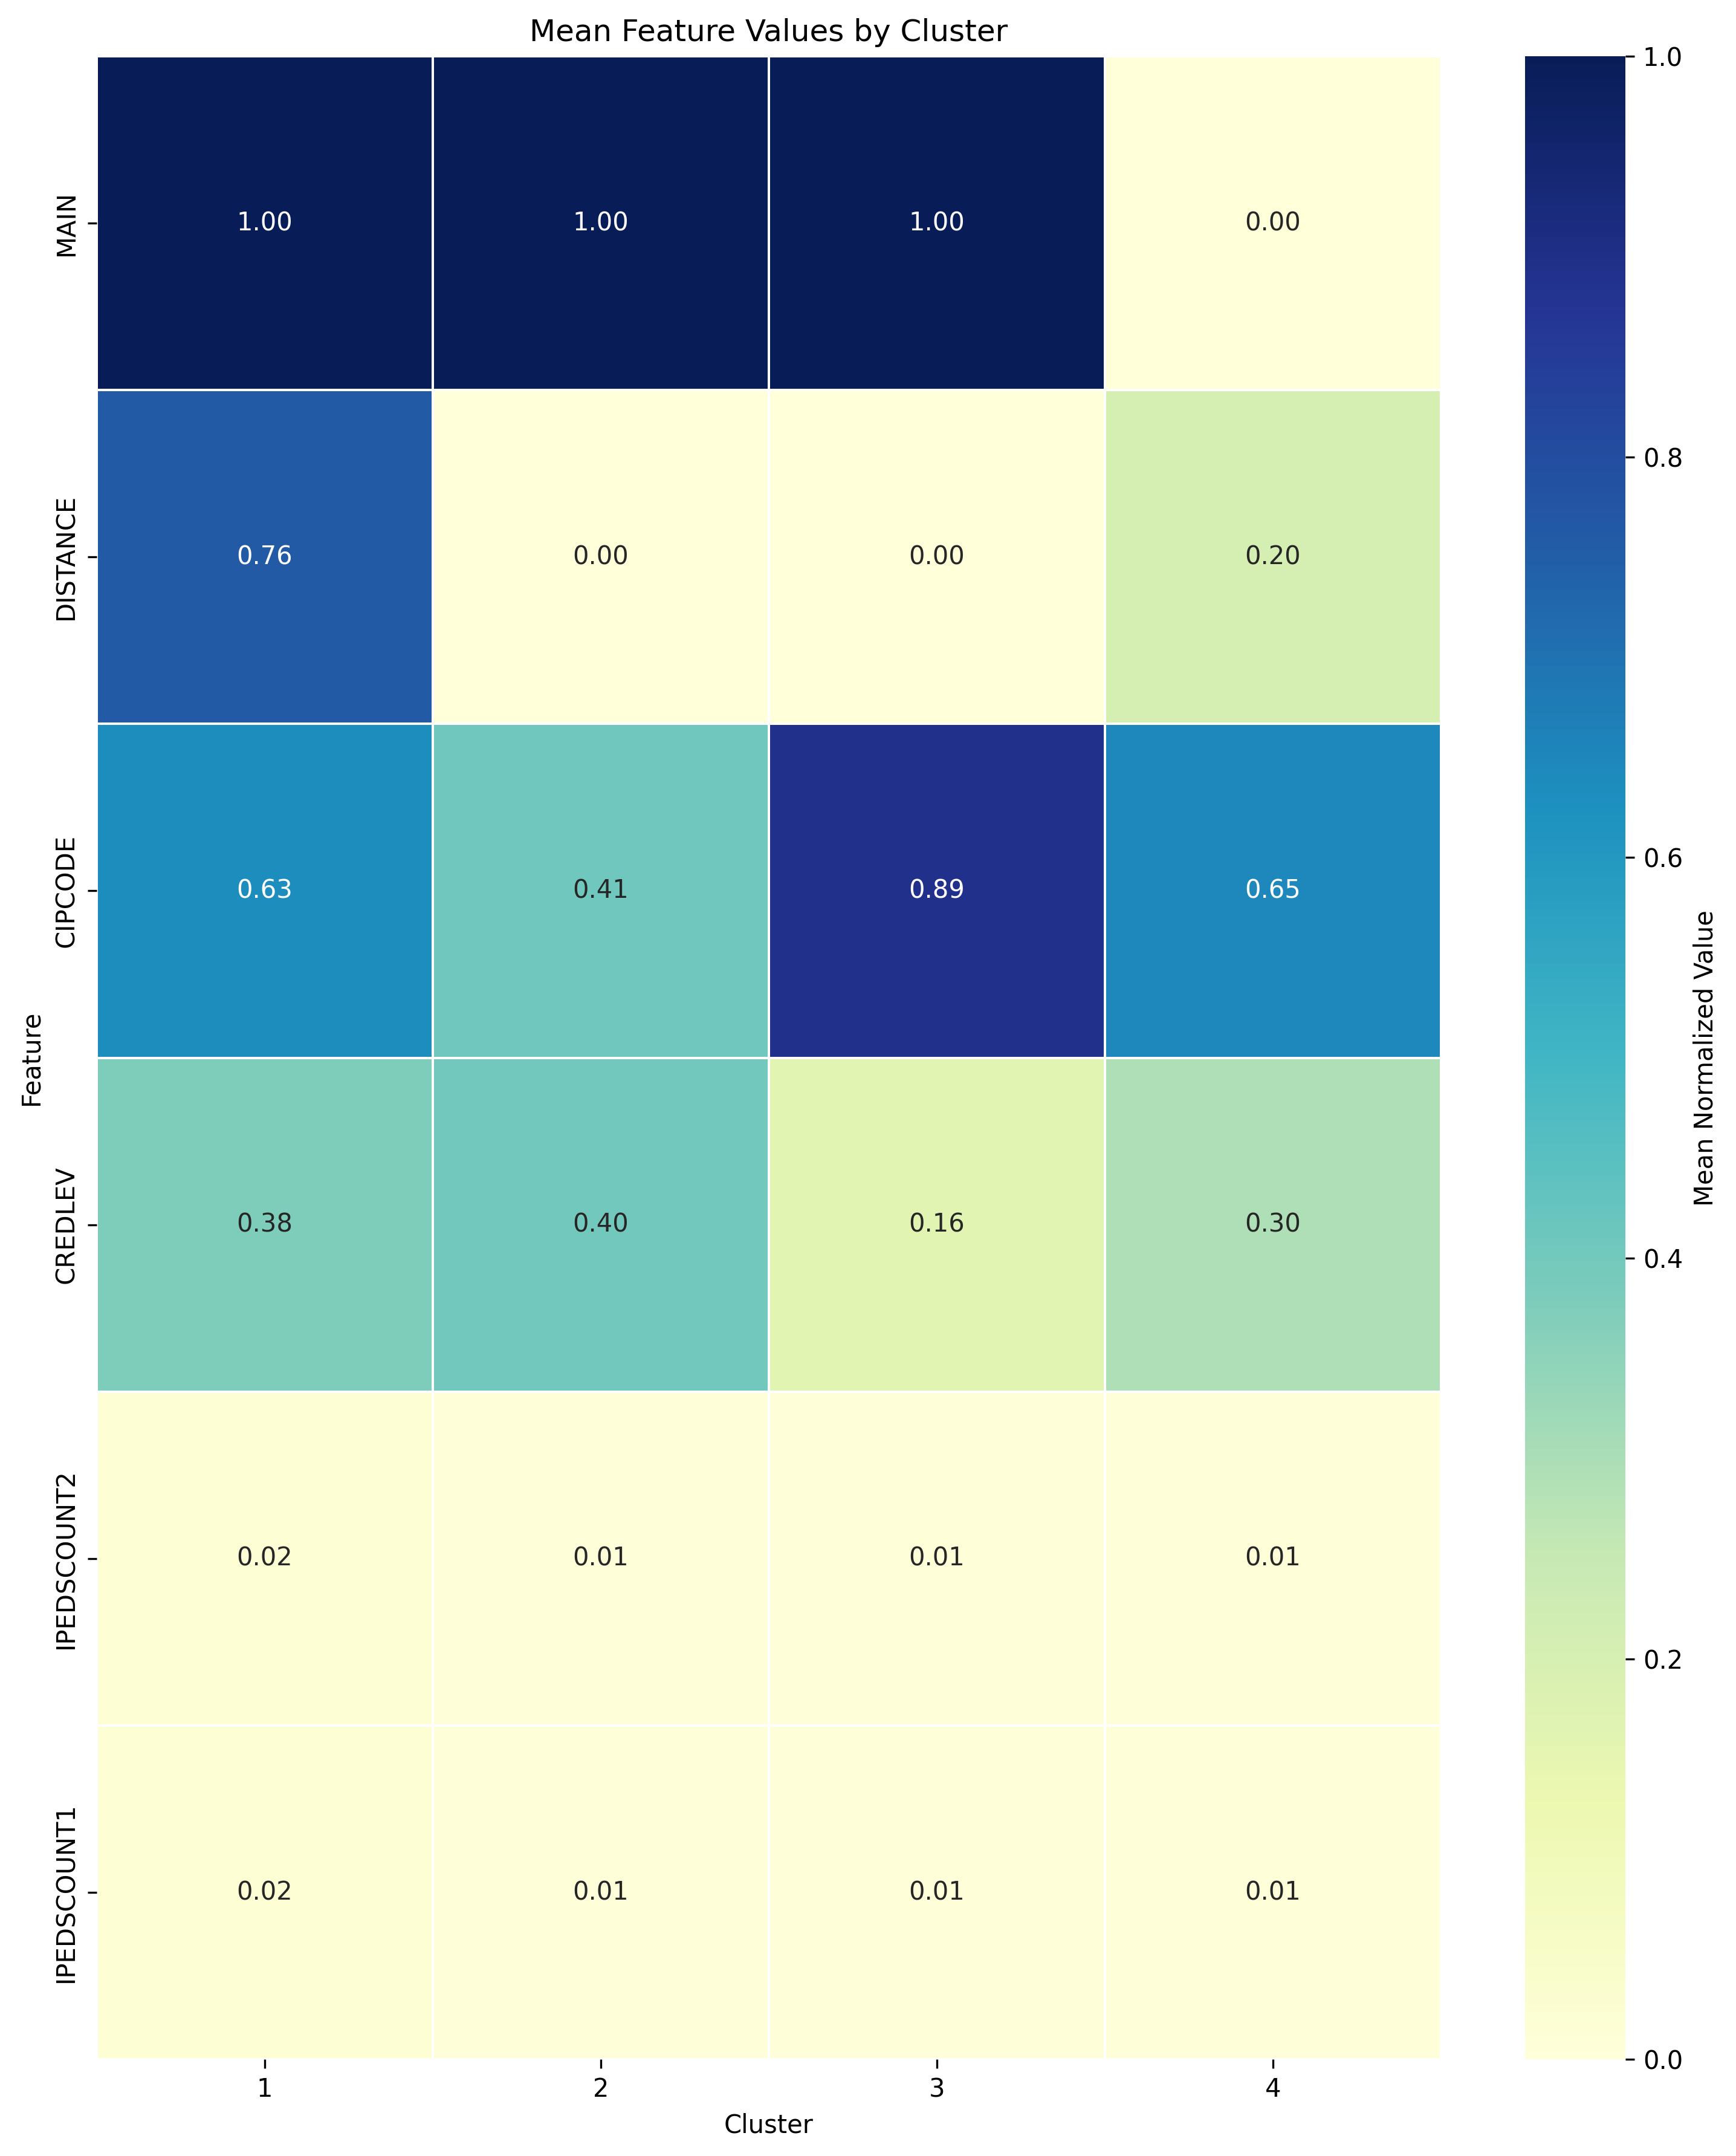

In [19]:
print("Feature importance heatmap visualization display...")

display(Image(filename="output/heatmap.png"))

### Trend Chart

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> A trend chart plots trends in a numeric feature across clusters. Save the image as <b><mark>trend_chart.png</mark></b>. Use <b><mark>display()</mark></b> to render the image for html file output. Do not use an <mark>html image</mark> tag in the markdown, or the image will not print in the html download.</span>
</div>

In [20]:
print("Creating trend chart to analyze a numeric feature across clusters...")

try:
    # Use the feature with the greatest variation between clusters
    trend_feature = important_features[0]

    # Calculate the mean original value of the feature for each cluster
    trend_data = (
        clustered_data.groupby("Cluster")[trend_feature]
        .mean()
        .reset_index()
        .sort_values("Cluster")
    )

    trend_chart_path = output_folder / "trend_chart.png"

    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=trend_data,
        x="Cluster",
        y=trend_feature,
        marker="o",
        markersize=9,
        linewidth=2.5,
        color="#2A6F97"
    )

    # Label each point with its mean value
    for _, row in trend_data.iterrows():
        plt.annotate(
            f"{row[trend_feature]:,.2f}",
            (row["Cluster"], row[trend_feature]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=9
        )

    plt.title(f"Average {trend_feature} Across Clusters")
    plt.xlabel("Cluster")
    plt.ylabel(f"Mean {trend_feature}")
    plt.xticks(trend_data["Cluster"])
    plt.grid(linestyle="--", alpha=0.35)
    plt.tight_layout()

    plt.savefig(
        trend_chart_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Numeric feature analyzed: {trend_feature}")
    print(f"Trend chart saved as: {trend_chart_path}")

except Exception as error:
    print(f"Error creating trend chart: {error}")
    raise

Creating trend chart to analyze a numeric feature across clusters...
Numeric feature analyzed: MAIN
Trend chart saved as: output/trend_chart.png


Trend chart visualization display...


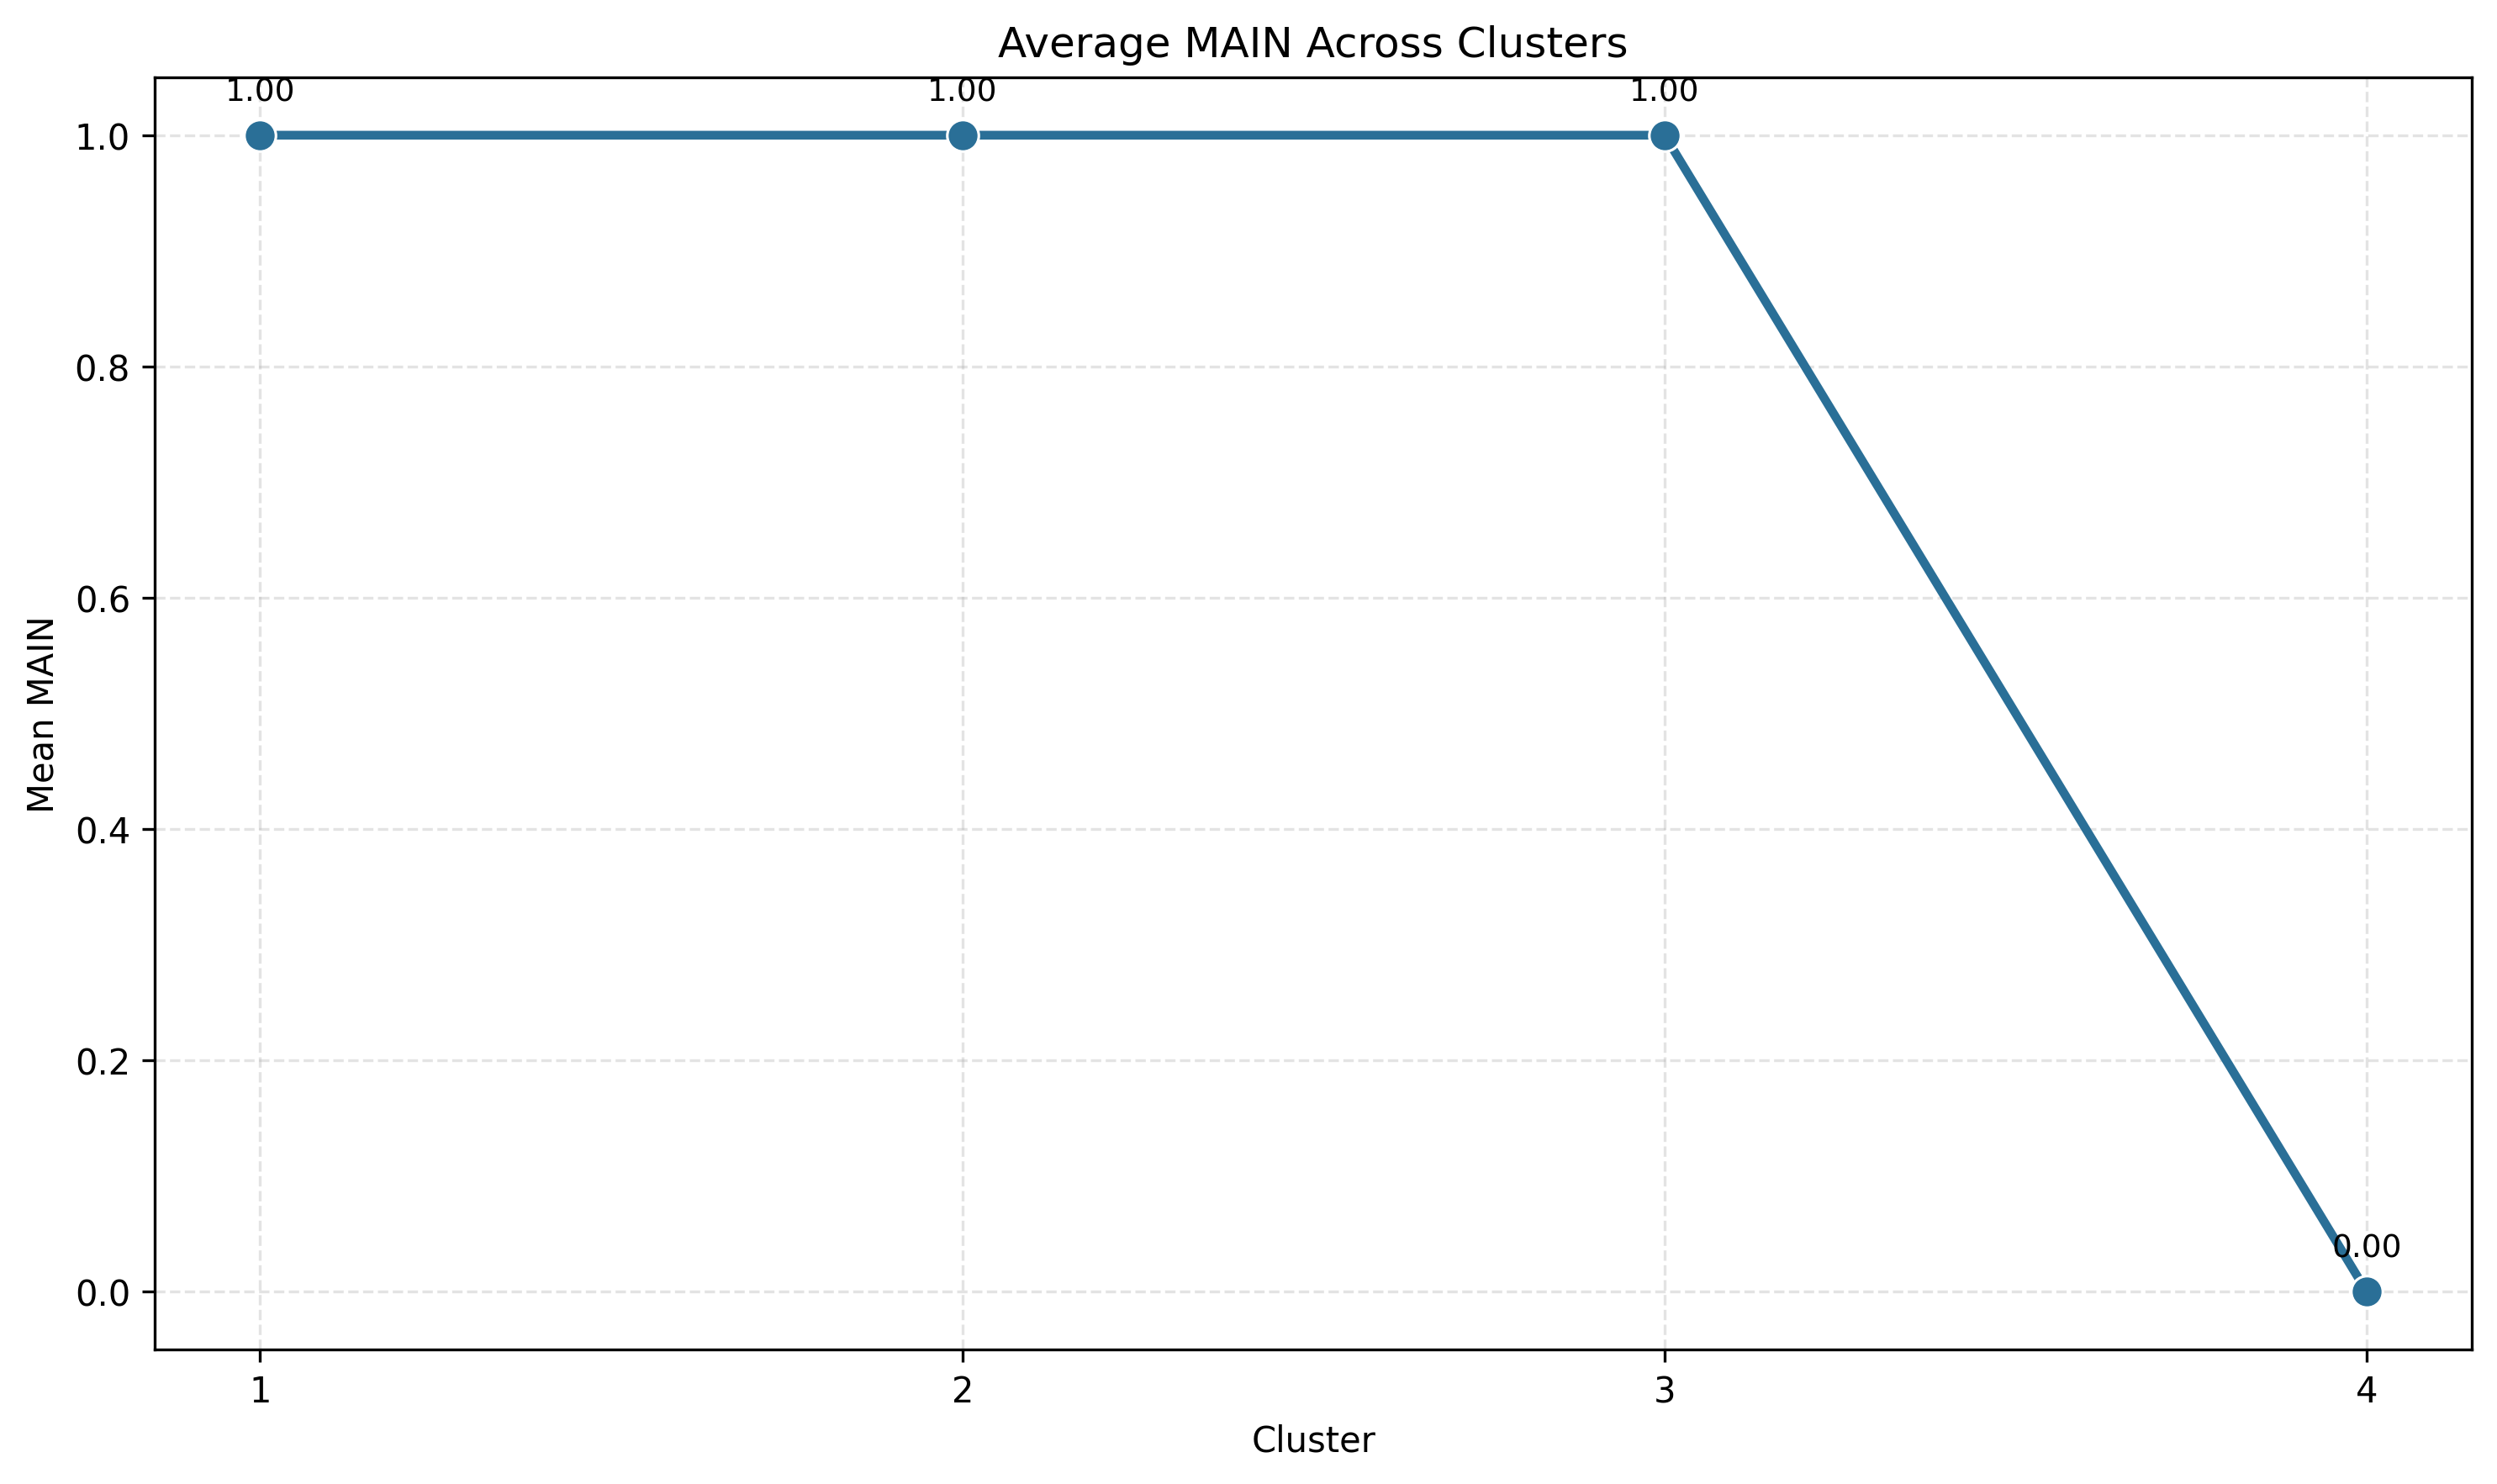

In [21]:
print("Trend chart visualization display...")

display(Image(filename="output/trend_chart.png"))

### Scatter Plot

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hints:</i></b> A scatter plot explores the relationship between two features, grouped by clusters. Save the image as <b><mark>scatter_plot.png</mark></b>. Use <b><mark>display()</mark></b> to render the image for html file output. Do not use an <mark>html image</mark> tag in the markdown, or the image will not print in the html download.</span>
</div>

In [22]:
print("Creating scatter plot of two features...")

try:
    if len(important_features) < 2:
        raise ValueError(
            "At least two numeric features are required for the scatter plot."
        )

    # Select the two features with the greatest variation across clusters
    x_feature = important_features[0]
    y_feature = important_features[1]

    scatter_plot_path = output_folder / "scatter_plot.png"

    plt.figure(figsize=(12, 8))

    sns.scatterplot(
        data=clustered_data,
        x=x_feature,
        y=y_feature,
        hue="Cluster",
        palette="Set2",
        s=55,
        alpha=0.7,
        edgecolor="white",
        linewidth=0.3
    )

    plt.title(f"Relationship Between {x_feature} and {y_feature}")
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend(title="Cluster")
    plt.grid(linestyle="--", alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        scatter_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"X-axis feature: {x_feature}")
    print(f"Y-axis feature: {y_feature}")
    print(f"Scatter plot saved as: {scatter_plot_path}")

except Exception as error:
    print(f"Error creating scatter plot: {error}")
    raise

Creating scatter plot of two features...
X-axis feature: MAIN
Y-axis feature: DISTANCE
Scatter plot saved as: output/scatter_plot.png


Scatter plot visualization display...


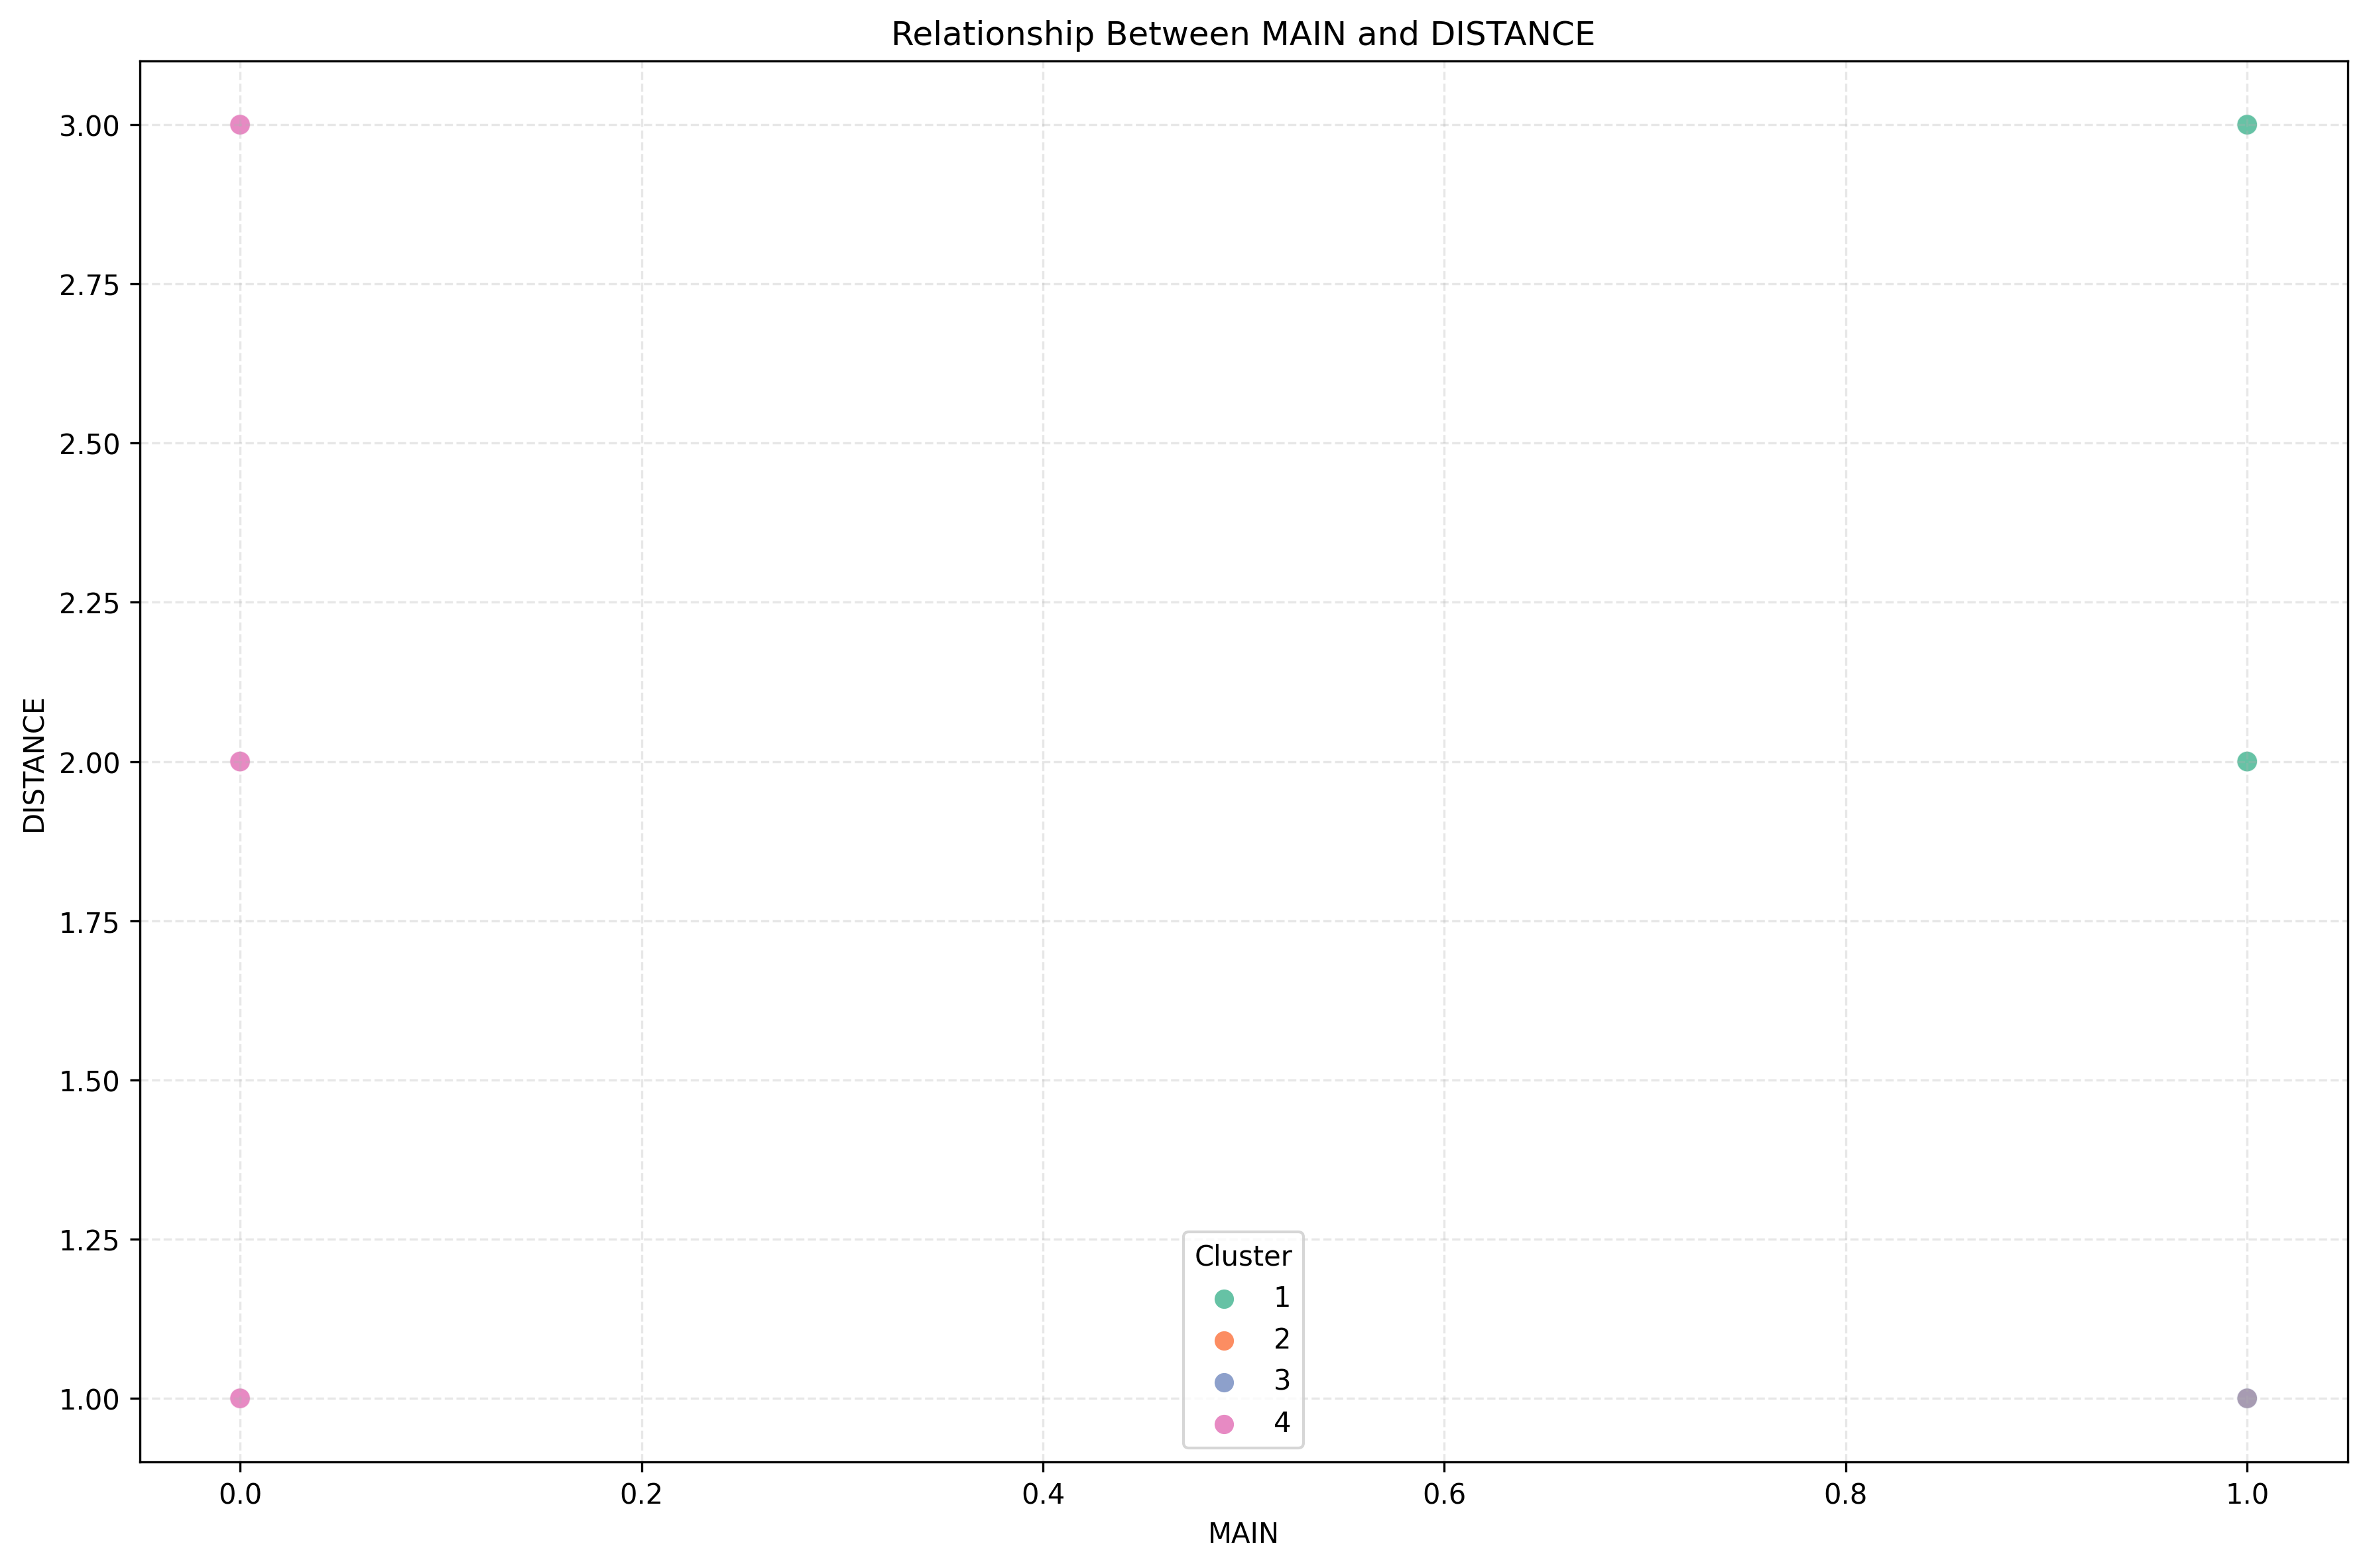

In [23]:
print("Scatter plot visualization display...")

display(Image(filename="output/scatter_plot.png"))

## Part 2: Reflection
<i>This part is to be completed in a word document, using the output above to answer the topics.</i>

### Identify patterns in the data. Consider the following:  
- Are there any clear trends, clusters, or outliers visible in your visualizations? 
- Are certain variables showing consistent behavior or relationships? 
- Are the patterns similar across different visualization types? 

### Draw conclusions from the patterns. Consider the following:  
- Are your conclusions clearly based on the patterns you observed? 
- Are your findings supported by multiple visuals or data points? 

### Explain how the visualizations validate your findings. Consider the following:  
- Are specific chart elements (e.g., color, scale, labels) helping to highlight your findings? 
- Are the insights you found something you could not easily see without the visuals? 

### Write a summary of the visualization choices you made. Include the following:  
- An explanation of the types of charts you used 
- An explanation of the formatting decisions to support visual clarity